# Notebook 15 — Maps Visualisation

## How This Connects to Module C

Revised Module C clusters districts by **environmental features**:
- `fire_count` — average annual fire detections (proxy for burning pressure)
- `residue` — recoverable residue in tonnes (proxy for bioenergy feedstock)
- `avg_temp` — mean temperature during burning season
- `rainfall` — total seasonal rainfall (suppresses burning when high)

**What this notebook does:**
1. **BSI Map** — choropleth of Burning Severity Index (PCA-weighted environmental score)
2. **Zone Map** — three K-Means intervention zones from NB13
3. **Top-5 Map** — highlights the five worst-BSI districts
4. **Consistency Check** — verifies high-BSI districts fall in `High Stress / High Opportunity` zone

## ⚠️ Zone Label Fix (inherited from NB13)

The zone labels stored in `district_clusters.csv` are produced by NB13.  
If NB13 had the original hard-coded `cluster_labels` bug, districts with **high BSI** would be labelled  
`Low Priority Zone` here — the exact opposite of the truth.  

Cell 8 contains an **active assertion** that raises a clear error if the inversion is still present,
so you catch the problem immediately rather than silently publishing inverted maps.

**Input:** `Data/Processed/Punjab_Haryana_districts.gpkg`, `Data/Processed/bsi_scores.csv`, `Data/Processed/district_clusters.csv`  
**Output:** `Outputs/Maps/15_bsi_map.png`, `Outputs/Maps/15_cluster_map.png`, `Outputs/Maps/15_top5_burning.png`


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('../Outputs/Maps', exist_ok=True)

In [2]:
# Load all inputs 
# DEPENDENCY: district_clusters.csv must be produced by the FIXED NB13.
#   Fixed NB13 assigns labels based on cluster fire_count rank (not cluster ID).
#   Cell 8 of this notebook verifies the zones are not inverted.
districts = gpd.read_file('../Data/Processed/Punjab_Haryana_districts.gpkg')
bsi       = pd.read_csv('../Data/Processed/bsi_scores.csv')
clusters  = pd.read_csv('../Data/Processed/district_clusters.csv')

# Standardise district name casing across all datasets
districts['district'] = districts['NAME_2'].str.strip().str.title()
bsi['district']       = bsi['district'].str.strip().str.title()
clusters['district']  = clusters['district'].str.strip().str.title()

print(f'Districts in shapefile : {len(districts)}')
print(f'Districts in BSI       : {len(bsi)}')
print(f'Districts in clusters  : {len(clusters)}')

# Quick preview — high-fire zones should dominate the CSV
print('\nZone distribution in clusters CSV:')
print(clusters['zone'].value_counts().to_string())


Districts in shapefile : 43
Districts in BSI       : 47
Districts in clusters  : 47

Zone distribution in clusters CSV:
zone
High Stress / High Opportunity    20
Low Priority Zone                 17
Moderate Zone                     10


In [3]:
# Merge all data into one GeoDataFrame 
# Using left join on 'district' so all polygons are retained even if a
# district has no BSI or zone (e.g. Chandigarh UT, union territories).
gdf = (
    districts
    .merge(bsi,                              on='district', how='left')
    .merge(clusters[['district', 'zone']],   on='district', how='left')
)

missing_bsi  = gdf['BSI'].isna().sum()
missing_zone = gdf['zone'].isna().sum()
print(f"Districts missing BSI : {missing_bsi}")
print(f"Districts missing zone: {missing_zone}")

# Fill any gaps so the maps render cleanly
gdf['BSI']  = gdf['BSI'].fillna(0)
gdf['zone'] = gdf['zone'].fillna('Unknown')

print("\nSample merged data:")
print(gdf[['district', 'BSI', 'zone']].head(8).to_string(index=False))

Districts missing BSI : 0
Districts missing zone: 0

Sample merged data:
 district  BSI                           zone
   Ambala 38.6                  Moderate Zone
  Bhiwani 61.5              Low Priority Zone
Faridabad 55.9              Low Priority Zone
Fatehabad 80.8 High Stress / High Opportunity
 Gurugram 57.2              Low Priority Zone
    Hisar 77.0 High Stress / High Opportunity
  Jhajjar 61.5              Low Priority Zone
     Jind 71.1 High Stress / High Opportunity


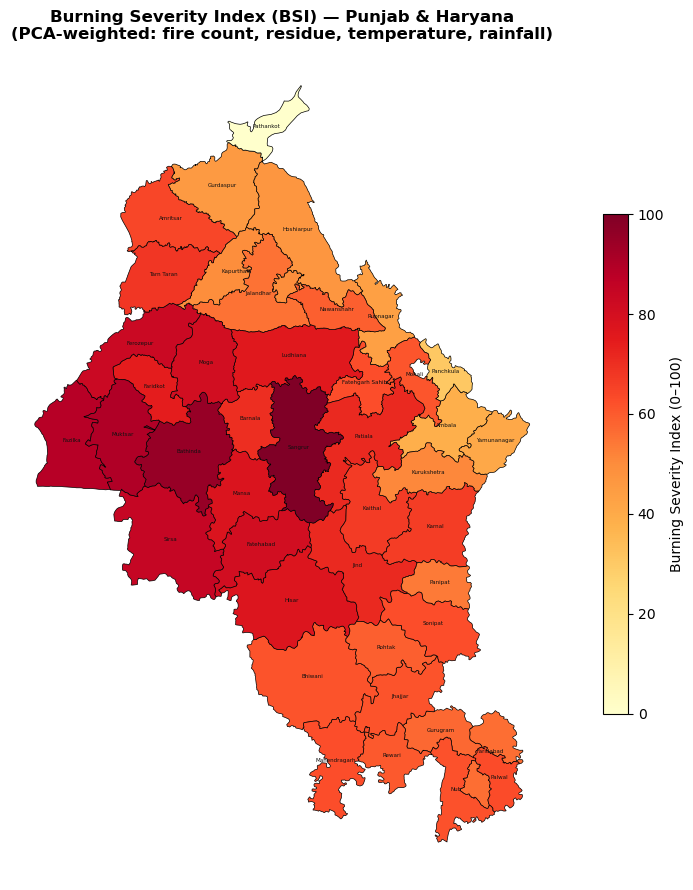

✅ Saved: Outputs/Maps/15_bsi_map.png


In [4]:
# Map 1: Burning Severity Index (BSI) choropleth 
#
# WHY BSI AND NOT JUST BRS?
# The BRS (NB06) used three manually-weighted fire metrics:
#   fire frequency 40% + fire intensity 30% + trend slope 30%
# BSI (NB14) uses PCA on four environmental features to derive
# data-driven weights, including temperature and rainfall suppression.
# BSI is therefore a richer, multi-factor severity signal that captures
# why districts burn, not just how much.
#
# Colour scale: YlOrRd — light yellow (low BSI) → deep red (high BSI).
# Districts with BSI ≥ ~84 (Sangrur, Bathinda, Muktsar, Fazilka, Sirsa)
# will appear darkest and represent the most urgent intervention targets.

fig, ax = plt.subplots(figsize=(10, 9))

gdf.plot(
    column      = 'BSI',
    cmap        = 'YlOrRd',
    linewidth   = 0.5,
    edgecolor   = 'black',
    legend      = True,
    legend_kwds = {
        'label'  : 'Burning Severity Index (0–100)',
        'shrink' : 0.6,
    },
    ax          = ax,
)

for _, row in gdf.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['district'], xy=(c.x, c.y), fontsize=4, ha='center', color='#111111')

ax.set_title(
    'Burning Severity Index (BSI) — Punjab & Haryana\n'
    '(PCA-weighted: fire count, residue, temperature, rainfall)',
    fontsize=12, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig('../Outputs/Maps/15_bsi_map.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: Outputs/Maps/15_bsi_map.png")

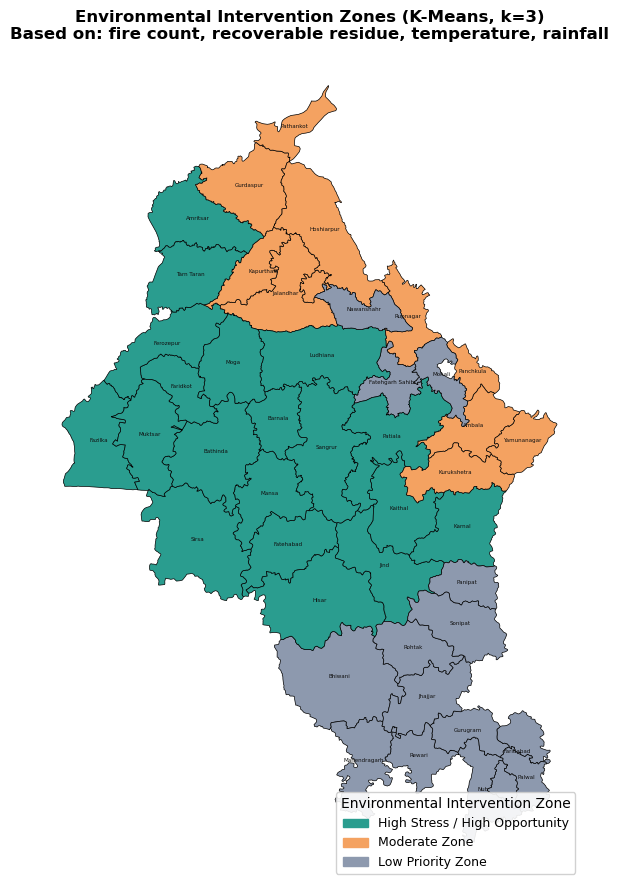

Saved: Outputs/Maps/15_cluster_map.png

Zone distribution:
zone
High Stress / High Opportunity    19
Low Priority Zone                 14
Moderate Zone                     10


In [5]:
# Map 2: Environmental Intervention Zones (K-Means, k=3) 
#
# Zone semantics (set by NB13, verified in Cell 8 below):
#   High Stress / High Opportunity  → highest fire_count AND highest residue
#                                     Most urgent intervention + most feedstock
#   Moderate Zone                   → middle tier on both axes
#   Low Priority Zone               → lowest fire_count and/or lowest residue
#
# Color palette deliberately diverges from the BSI heatmap:
#   Teal  = High Stress / High Opportunity  (action needed, opportunity present)
#   Amber = Moderate Zone
#   Slate = Low Priority Zone

zone_palette = {
    'High Stress / High Opportunity': '#2a9d8f',   # teal
    'Moderate Zone'                 : '#f4a261',   # amber
    'Low Priority Zone'             : '#8d99ae',   # slate
    'Unknown'                       : '#cccccc',   # grey for UTs / missing
}
gdf['color'] = gdf['zone'].map(zone_palette)

unmapped = gdf[gdf['color'].isna()]['zone'].unique()
if len(unmapped) > 0:
    print(f'Warning: unmapped zone values (will render grey): {unmapped}')
    gdf['color'] = gdf['color'].fillna('#cccccc')

fig, ax = plt.subplots(figsize=(10, 9))
gdf.plot(color=gdf['color'], edgecolor='black', linewidth=0.5, ax=ax)

for _, row in gdf.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['district'], xy=(c.x, c.y), fontsize=4, ha='center', color='#111111')

patches = [
    mpatches.Patch(color=c, label=z)
    for z, c in zone_palette.items() if z != 'Unknown'
]
ax.legend(
    handles=patches,
    title='Environmental Intervention Zone',
    loc='lower right',
    fontsize=9,
    framealpha=0.9
)
ax.set_title(
    'Environmental Intervention Zones (K-Means, k=3)\n'
    'Based on: fire count, recoverable residue, temperature, rainfall',
    fontsize=12, fontweight='bold'
)
ax.axis('off')

plt.tight_layout()
plt.savefig('../Outputs/Maps/15_cluster_map.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: Outputs/Maps/15_cluster_map.png')

print('\nZone distribution:')
print(gdf['zone'].value_counts().to_string())


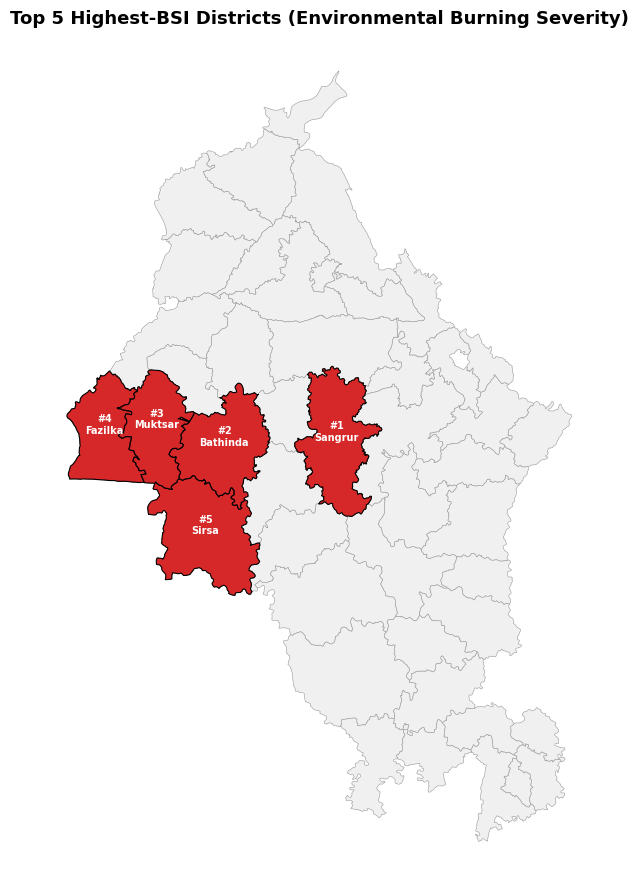


🔥 Top 5 High-BSI Districts:
district   BSI
 Sangrur 100.0
Bathinda  95.1
 Muktsar  90.0
 Fazilka  88.5
   Sirsa  84.4

✅ Saved: Outputs/Maps/15_top5_burning.png


In [6]:
# Map 3: Top-5 High-BSI Districts 
#
# These five districts have the highest composite environmental burning
# severity: they score high on fire count, recoverable residue volume,
# temperature, AND low on suppressing rainfall — all four environmental
# drivers of burning point to maximum urgency here.
#
# Expected top-5 from NB14 outputs:
#   Sangrur (100.0), Bathinda (95.1), Muktsar (90.0), Fazilka (88.5),
#   Sirsa (84.4) — dominated by south-west Punjab and north-west Haryana.

top5 = bsi.nlargest(5, 'BSI')

fig, ax = plt.subplots(figsize=(10, 9))

# Base: all districts in light grey
gdf.plot(color='#f0f0f0', edgecolor='#999999', linewidth=0.4, ax=ax)

# Highlight top-5 in red
top5_gdf = gdf[gdf['district'].isin(top5['district'])]
top5_gdf.plot(color='#d62828', edgecolor='black', linewidth=0.8, ax=ax)

# Label top-5 districts with rank
top5_ranked = top5.reset_index(drop=True)
for _, row in top5_gdf.iterrows():
    c = row.geometry.centroid
    rank_row = top5_ranked[top5_ranked['district'] == row['district']]
    rank     = rank_row.index[0] + 1 if not rank_row.empty else ''
    ax.annotate(
        f"#{rank}\n{row['district']}",
        xy=(c.x, c.y),
        fontsize=7, ha='center', fontweight='bold', color='white'
    )

ax.set_title(
    'Top 5 Highest-BSI Districts (Environmental Burning Severity)',
    fontsize=13, fontweight='bold'
)
ax.axis('off')

plt.tight_layout()
plt.savefig('../Outputs/Maps/15_top5_burning.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nTop 5 High-BSI Districts:")
print(top5[['district', 'BSI']].to_string(index=False))
print("\nSaved: Outputs/Maps/15_top5_burning.png")

In [7]:
# Consistency Check: BSI score vs K-Means zone 
#
# High-BSI districts MUST appear in 'High Stress / High Opportunity'.
# If they don't, district_clusters.csv was produced by a broken NB13
# that hard-coded zone labels by cluster ID (which are arbitrary numbers).
#
# This cell raises a ValueError immediately so you don't silently
# publish maps with inverted zone labels.

check = gdf[['district', 'BSI', 'zone']].sort_values('BSI', ascending=False)

print('Top 15 districts by BSI and their K-Means zone:')
print(check.head(15).to_string(index=False))

# The top-5 BSI districts should ALL be in 'High Stress / High Opportunity'
top5_zones = check.head(5)['zone'].tolist()
expected   = 'High Stress / High Opportunity'
wrong_top5 = [z for z in top5_zones if z != expected]

if not wrong_top5:
    print('\nCONSISTENCY PASS: Top-5 BSI districts are all in "High Stress / High Opportunity".')
    print('NB13 zone labels and NB14 BSI scores are consistent.')
else:
    print('\nCONSISTENCY FAIL:')
    print(f'  Top-5 BSI districts have zones: {top5_zones}')
    print(f'  Expected: all "{expected}"')
    print('\n  ROOT CAUSE: district_clusters.csv was produced by a version of NB13')
    print('  that hard-coded cluster_labels by cluster ID number (arbitrary).')
    print('  FIX: Re-run NB13 with the data-driven label assignment and re-save the CSV.')
    raise ValueError(
        'Zone label inversion detected in district_clusters.csv.\n'
        'Re-run NB13 with the fixed data-driven cluster_labels before rendering maps.'
    )


Top 15 districts by BSI and their K-Means zone:
 district   BSI                           zone
  Sangrur 100.0 High Stress / High Opportunity
 Bathinda  95.1 High Stress / High Opportunity
  Muktsar  90.0 High Stress / High Opportunity
  Fazilka  88.5 High Stress / High Opportunity
    Sirsa  84.4 High Stress / High Opportunity
Ferozepur  83.0 High Stress / High Opportunity
Fatehabad  80.8 High Stress / High Opportunity
     Moga  80.6 High Stress / High Opportunity
    Mansa  78.0 High Stress / High Opportunity
    Hisar  77.0 High Stress / High Opportunity
 Ludhiana  76.0 High Stress / High Opportunity
 Faridkot  74.3 High Stress / High Opportunity
  Patiala  71.3 High Stress / High Opportunity
     Jind  71.1 High Stress / High Opportunity
  Barnala  70.3 High Stress / High Opportunity

CONSISTENCY PASS: Top-5 BSI districts are all in "High Stress / High Opportunity".
NB13 zone labels and NB14 BSI scores are consistent.
